# Convergence per Attack per Algorithm

In [1]:
%load_ext autoreload
import sys
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime
import copy

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed, save_to_pkl, load_from_pkl
from lib.classifier import ByzClassifier, load_run, save_run
from lib.system import SystemSimulator
from lib.metrics import MetricsCalculator
from lib.config import BASE_CONF, NUM_NODES

In [4]:
# generic helper functions
fmt = lambda sec : f"{sec // 60}m {sec % 60:.2f}s"

def convert(o):
    if isinstance(o, np.generic):
        return o.item()
    raise TypeError(f'{type(o)} not serializable')

def get_graph_args(num_byz_nodes, tar_dir_het_param):
    graph_args = {
        'ws_k': 6,
        'ws_p': 0.1,
        'rand_reg_deg':10,
        'geom_radius':0.4,
        'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
    }
    if(num_byz_nodes == 5):
        r_ub = {
            'erdos-renyi': 0.1461,
            'random-regular': 0.1195,
            'watts-strogatz': 0.0711,
            'geometric': 0.0625,
            'complete': 0.3438
        }
        return graph_args, r_ub
        
    elif(num_byz_nodes <= 9 and num_byz_nodes > 5):
        r_ub = {
            'erdos-renyi': 0.043,
            'random-regular': 0.0,
            'watts-strogatz': 0.0,
            'geometric': 0.0,
            'complete': 0.0799
        }
        return graph_args, r_ub
    else: raise ValueError(f'No graph parameters for b={num_byz_nodes}')

In [5]:
RUN_DIR = os.path.join(Path().resolve(), "baseline")
config = copy.deepcopy(BASE_CONF)
config['train']['b'] = 5
config['sys']['b'] = config['train']['b'] 
config['train']['clf_model'] = 'xgb'
config['data_heterogeneity'] = 100
config['reg_param'] = 1

b = config['train']['b']
graph_args, r_ub = get_graph_args(b,10)
config['graph_args'] = graph_args
config['graph_weights'] = 'MH_gen'
config['graph_type']='random-regular'

config['sys']['dropout'] = min(r_ub[config['graph_type']], 0.2)

config['train']['fpr_mean'] = 0.2
config['train']['fpr_spread'] = 0.05

gamma_train = np.clip((config['train']['fpr_spread']*np.linspace(-1,1,NUM_NODES)) + config['train']['fpr_mean'], 0, 0.95)
config['train']['gamma_C'] = gamma_train

graphs = ['random-regular','watts-strogatz', 'geometric', 'erdos-renyi']
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD', 'ORACLE', 'IOS', 'SCC', 'TriMean', 'CooMed']
ALGS_TEST = ['RDSGD', 'ORACLE']
COLORS = dict(zip(ALGS, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']))

# Fix a test attack
atk = 'gaussian'
RUN_ID=2
local_seed = 333

In [6]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], b)
proj_const_estimator = ProjConstEstimator(config, global_dataset, gf) 
clf = ByzClassifier(config, global_dataset, gf)
sys_sim = SystemSimulator(config, global_dataset, gf)
mc = MetricsCalculator(config, global_dataset, rng('mc','exp11'))

In [7]:
%%time
config['graph_args']['MH_target_pi'] = (1 - config['train']['gamma_C']) * np.full(NUM_NODES, 1.0/NUM_NODES)

pkl_file = os.path.join(RUN_DIR, f'clf_sim_data_{config['graph_type']}_{config['sys']['b']}_{local_seed}.pkl.gz')
if os.path.exists(pkl_file):
    conf = load_run(clf, pkl_file)
    proj_const = conf['proj_const']
else:
    proj_const_estimator.configure(config, seed('proj',local_seed))
    proj_const = proj_const_estimator.estimate()
    clf_sim_data = clf.run_simulations(config, proj_const, seed('clf',local_seed))
    save_run(clf, pkl_file, {'proj_const':proj_const})

CPU times: user 1.09 s, sys: 55 μs, total: 1.09 s
Wall time: 116 ms


In [8]:
%%time
clf_est, clf_preproc = clf.fit()
clf_op_pt = clf.calc_optimal_op_pt()
clf_metrics = clf.test()

CPU times: user 46.8 s, sys: 89.1 ms, total: 46.8 s
Wall time: 14.3 s


In [14]:
config['sys']['fpr_spread'] = 0.003
gamma_sys = np.clip(clf_op_pt['C_fpr'] + (np.linspace(-1, 1, NUM_NODES) * config['sys']['fpr_spread']), 0, 0.95)
clf_thr = clf.threshold_at_fpr(gamma_sys)

config['graph_args']['MH_target_pi'] = (1-gamma_sys) * (np.full(NUM_NODES, 1.0/NUM_NODES))
clf_thr = clf.threshold_at_fpr(gamma_sys)

In [11]:
%%time
sim_params = {
    'algorithms': ALGS_TEST,
    'atk_type': atk,
    'threat_model': 'T3',
    'seed': local_seed
}

params_C = dict()

# Specifies RDSGD_ORACLE Parameters
params_C['C_fpr'] = clf_thr['fpr_ach']
params_C['C_fnr'] = clf_thr['fnr_ach']

# Specifies RDSGD Parameters
params_C['C_tau'] = clf_thr['C_tau']

sys_sim.init_simulation(config, proj_const, clf_preproc, clf_est, params_C, seed('sys', local_seed))
df = sys_sim.simulate(sim_params)

=========================RDSGD==========================
[k=50] train_loss: [2.074,2.088],test_acc: [0.850,0.851]
[k=100] train_loss: [2.074,2.088],test_acc: [0.852,0.854]
[k=150] train_loss: [2.074,2.088],test_acc: [0.851,0.852]
=========================ORACLE=========================
[k=50] train_loss: [2.073,2.089],test_acc: [0.849,0.852]
[k=100] train_loss: [2.074,2.088],test_acc: [0.849,0.851]
[k=150] train_loss: [2.073,2.088],test_acc: [0.850,0.852]
CPU times: user 21min 10s, sys: 9.96 s, total: 21min 20s
Wall time: 1min 7s


In [12]:
df.to_csv(os.path.join(RUN_DIR,f'{config['graph_type']}_{atk}_b_{b}_results_dataset.csv'))

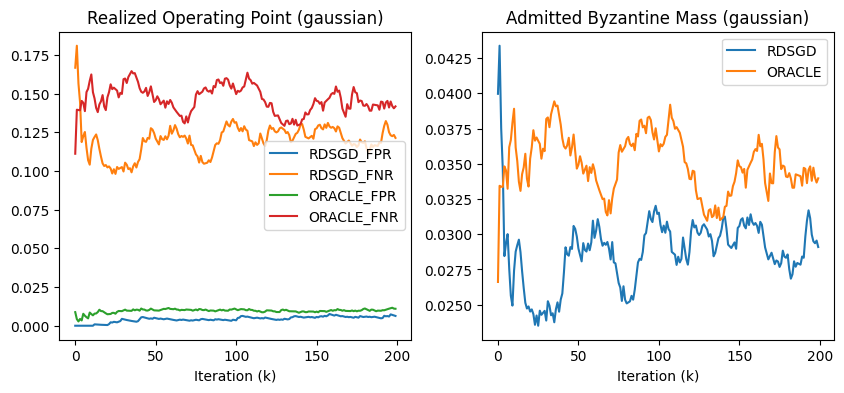

In [13]:
# Plot Realized FPR and FNR 
fig, ax = plt.subplots(1,2,figsize=(10,4))
for idx, alg in enumerate(ALGS_TEST):
    ax[0].plot(df.loc[alg, 'gamma_k'].ewm(com=20, adjust=True).mean(), label=f'{alg}_FPR')
    ax[0].plot(df.loc[alg, 'beta_k'].ewm(com=20, adjust=True).mean(), label=f'{alg}_FNR')
    ax[1].plot(df.loc[alg, 'byz_w_k'].ewm(com=20, adjust=True).mean(), label=alg)
ax[0].set(title=f'Realized Operating Point ({atk})', xlabel='Iteration (k)', ylabel='')
ax[1].set(title=f'Admitted Byzantine Mass ({atk})', xlabel='Iteration (k)', ylabel='')
ax[0].legend()
ax[1].legend()
plt.show()
fig.savefig(os.path.join(RUN_DIR,f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_realized_fpr_fnr.png'))